# Main script

## Part (i): loading data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skdim
import os
# load .mat data
import scipy.io
from scipy.linalg import pinvh

import xarray as xr
# add ../ to the path
import sys
sys.path.append('../')

import src.model as model

%load_ext autoreload
%autoreload 2

data_path  = os.getenv('DATA_PATH')
param_path = os.getenv('PARAM_PATH')
folder = data_path
# ------------------------------------------------- LOAD SIMULATION DATA -------------------------------------------------
# get the DATA_PATH from the environment variable
X_filename           = 'trainingAll4D_Eb_sim_standardized.mat'
Y_filename           = 'trainingAll4D_Ns_sim_masked_standardized.mat'
H_filename           = 'H_gridded.mat'
Y_obs_filename       = "Ns_obs_gridded.mat"
mask_filename        = 'training_mask.mat' 
model_bound_filename = 'training_mask_domain_continuous.mat'
# also the mean and std of Eb for reverse standardization
Eb_mean_filename     = 'trainingAll_Eb_sim_mean.mat'
Eb_std_filename      = 'trainingAll_Eb_sim_std.mat'
# also the mean and std of Ns for standardization of observed data
Ns_mean_filename     = 'trainingAll_Ns_sim_mean_masked.mat'
Ns_std_filename      = 'trainingAll_Ns_sim_std_masked.mat'
# others
coord_filename       = "trainingAll_image_coord.mat"

# preprocessing parameter file: read the csv file
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]
Ns_standardize_epsilon = preprocess_param['Ns_standardization_epsilon'].values[0]
print("Eb_standardize_epsilon:", Eb_standardize_epsilon)
print("Ns_standardize_epsilon:", Ns_standardize_epsilon)


X_data           = scipy.io.loadmat(folder + X_filename)
Y_data           = scipy.io.loadmat(folder + Y_filename)
flight_mask_data = scipy.io.loadmat(folder + mask_filename) # this is the flightline mask
H_data           = scipy.io.loadmat(folder + H_filename)
model_bound_data = scipy.io.loadmat(folder + model_bound_filename) # this is model domain mask
coord_data       = scipy.io.loadmat(folder + coord_filename)
# standardization data for Eb
Eb_mean          = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std           = scipy.io.loadmat(folder + Eb_std_filename)

# load
Eb_standardized = X_data['Eb_standardized']
Ns_standardized = Y_data['Ns_standardized_masked']
# replace nan by 0
Eb_mean = np.nan_to_num(Eb_mean['Eb_mean'], nan=0.0).flatten()
Eb_std  = np.nan_to_num(Eb_std['Eb_std'], nan=0.0).flatten()

# load model boundary
model_bound_data_ori = model_bound_data['in_domain_mask'].astype(bool)

x_coord = coord_data['training_coord'][0][0][0]
y_coord = coord_data['training_coord'][0][0][1]
extent = np.array([x_coord.min(), x_coord.max(), y_coord.max(), y_coord.min()])/1e3 # convert to km (left, right, bottom, top), imshow by default is inverted in y-axis

# -------------------------------------------------- LOAD OBSERVATION DATA --------------------------------------------------
Y_obs_data   = scipy.io.loadmat(folder + Y_obs_filename)
# standardization data for Ns
Ns_mean_data = scipy.io.loadmat(folder + Ns_mean_filename)
Ns_std_data  = scipy.io.loadmat(folder + Ns_std_filename)
Ns_mean = Ns_mean_data['Ns_mean_masked']
Ns_std = Ns_std_data['Ns_std_masked']  

Y_obs_data     = Y_obs_data['atten_rate_grid']
atten_rate_avg = Y_obs_data['atten_avg'][0][0]

# apply flightline masking to the standardization mean and std
flight_mask = flight_mask_data['mask']
flight_mask_bool = flight_mask.astype(bool)
Ns_mean_masked = Ns_mean.copy()
Ns_mean_masked[~flight_mask_bool] = 0 # set the mean to 0
Ns_std_masked = Ns_std.copy()
Ns_std_masked[~flight_mask_bool] = 1 # set the std to 1

Ns_mean_masked = Ns_mean_masked.flatten()   
Ns_std_masked  = Ns_std_masked.flatten()

print('Shape of Eb_standardized:', Eb_standardized.shape)
print('Shape of Ns_standardized:', Ns_standardized.shape)
print('Shape of domain mask:', model_bound_data_ori.shape)
print('Shape of flight mask:', flight_mask_bool.shape)


Eb_standardize_epsilon: 1287.4819202075
Ns_standardize_epsilon: 0.262291780650704
Shape of Eb_standardized: (256, 256, 1, 1042)
Shape of Ns_standardized: (256, 256, 1, 1042)
Shape of domain mask: (256, 256)
Shape of flight mask: (256, 256)


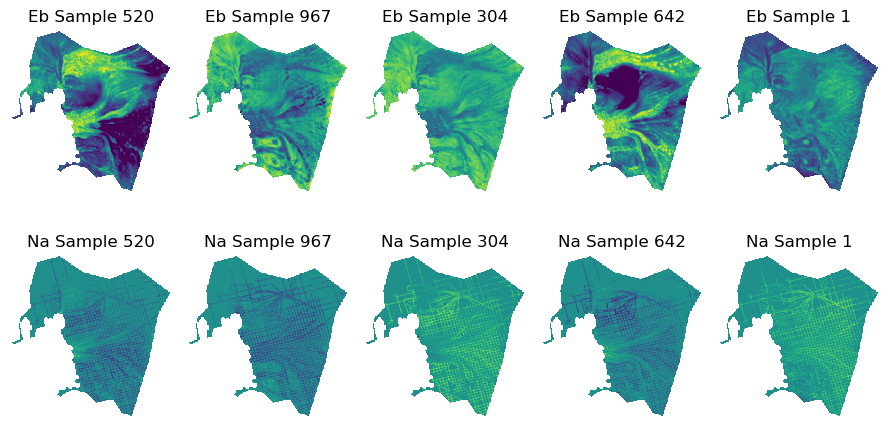

In [2]:
# initialize the model object
md = model.model(extent=extent, coord=(x_coord, y_coord))
md.load_sim_data(Eb_standardized, Ns_standardized, 
                 domain_mask=model_bound_data_ori, 
                 flight_mask=flight_mask_bool, 
                 show_plot=True)

md.load_standardization_data(X_mean=Eb_mean, X_std=Eb_std,
                             Y_mean=Ns_mean_masked, Y_std=Ns_std_masked,
                             X_epsilon=Eb_standardize_epsilon, Y_epsilon=Ns_standardize_epsilon)

## Part (ii): inspecting data dimension with PCA

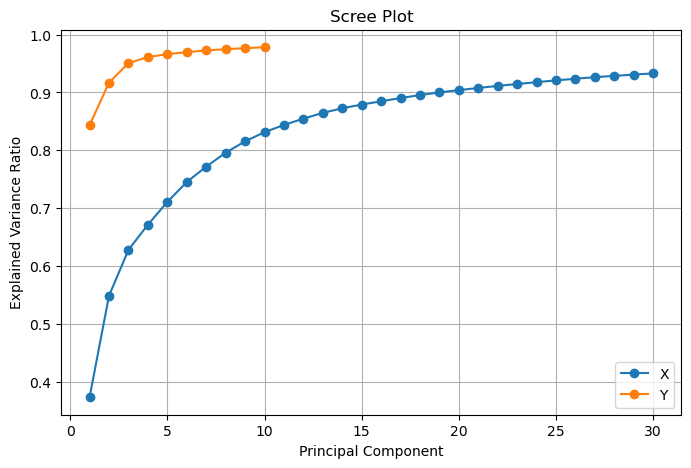

In [3]:
md.pca_scree(n_component_x=30, n_component_y=10)

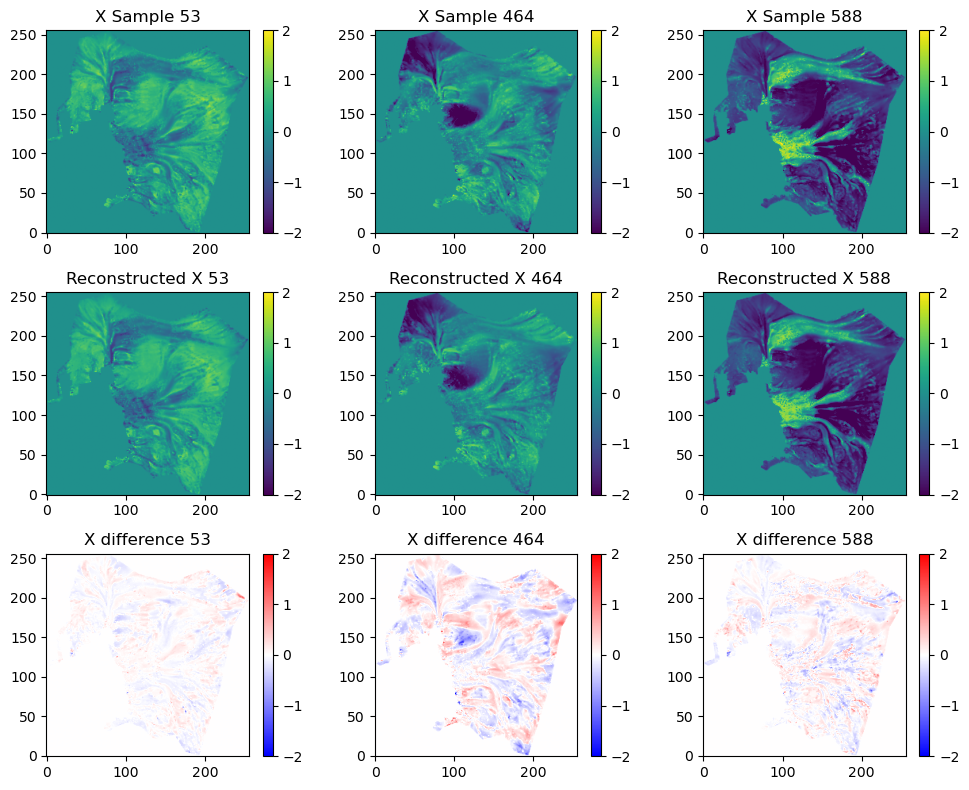

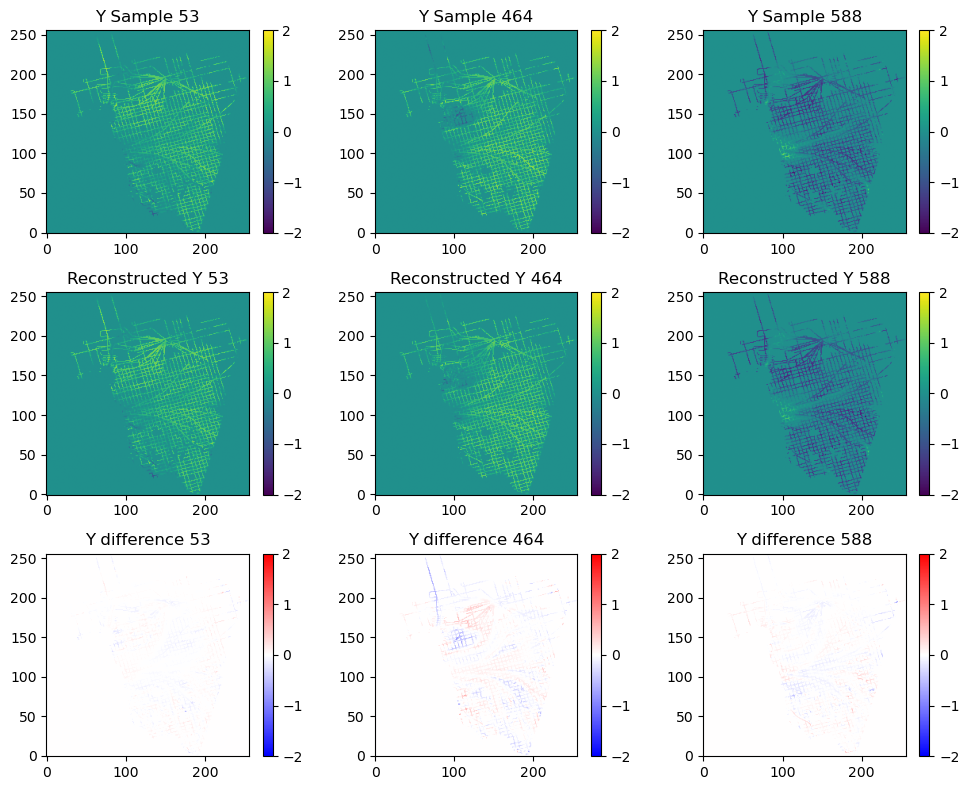

In [4]:
md.pca_recon_inspection(n_component_x=30, n_component_y=10)

## Part (iii): Dimension reduction and derive the informative prior

Shape of XY_train: (833, 33)
Shape of XY_validation: (104, 33)
Shape of XY_test: (105, 33)
GMM training completed in 0.00 seconds.
k*ln(n): 3994.6699834471046  - 2*L: 209984.44899592776 BIC: 213979.11897937485
n_components: 1 BIC: 213979.11897937485
GMM training completed in 0.03 seconds.
k*ln(n): 7996.065000536377  - 2*L: 195517.3296858958 BIC: 203513.39468643218
n_components: 2 BIC: 203513.39468643218
GMM training completed in 0.11 seconds.
k*ln(n): 11997.460017625648  - 2*L: 194320.40241326272 BIC: 206317.86243088837
n_components: 3 BIC: 206317.86243088837
GMM training completed in 0.04 seconds.
k*ln(n): 15998.85503471492  - 2*L: 189454.91388665256 BIC: 205453.76892136747
n_components: 4 BIC: 205453.76892136747
GMM training completed in 0.04 seconds.
k*ln(n): 20000.250051804192  - 2*L: 185297.72151660593 BIC: 205297.9715684101
n_components: 5 BIC: 205297.9715684101
GMM training completed in 0.04 seconds.
k*ln(n): 24001.645068893464  - 2*L: 181576.97897741737 BIC: 205578.62404631084


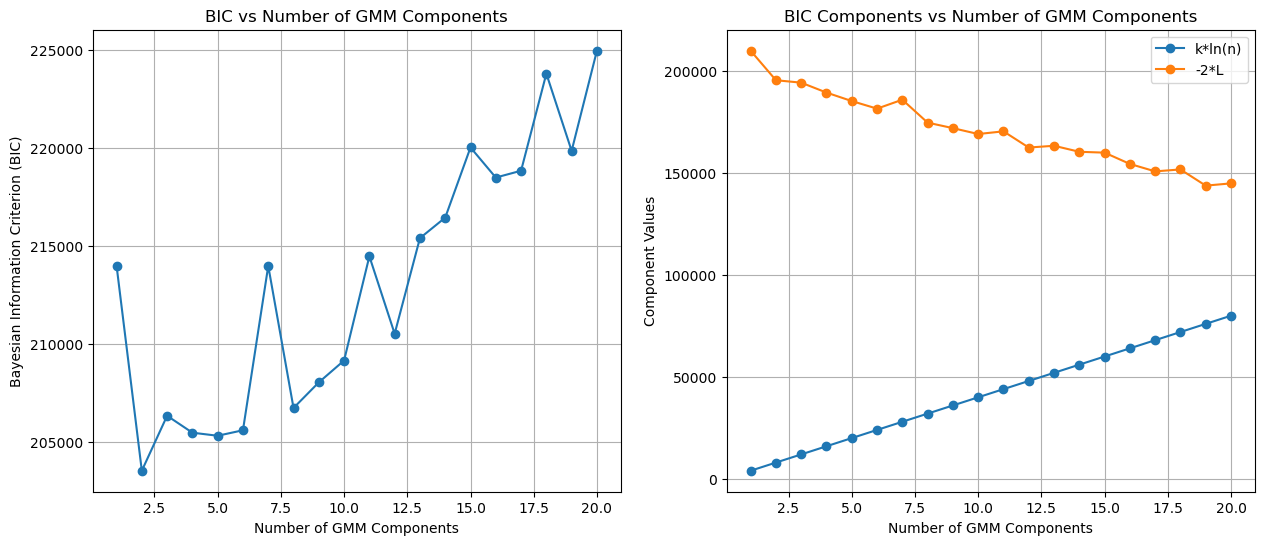

GMM training completed in 0.09 seconds.


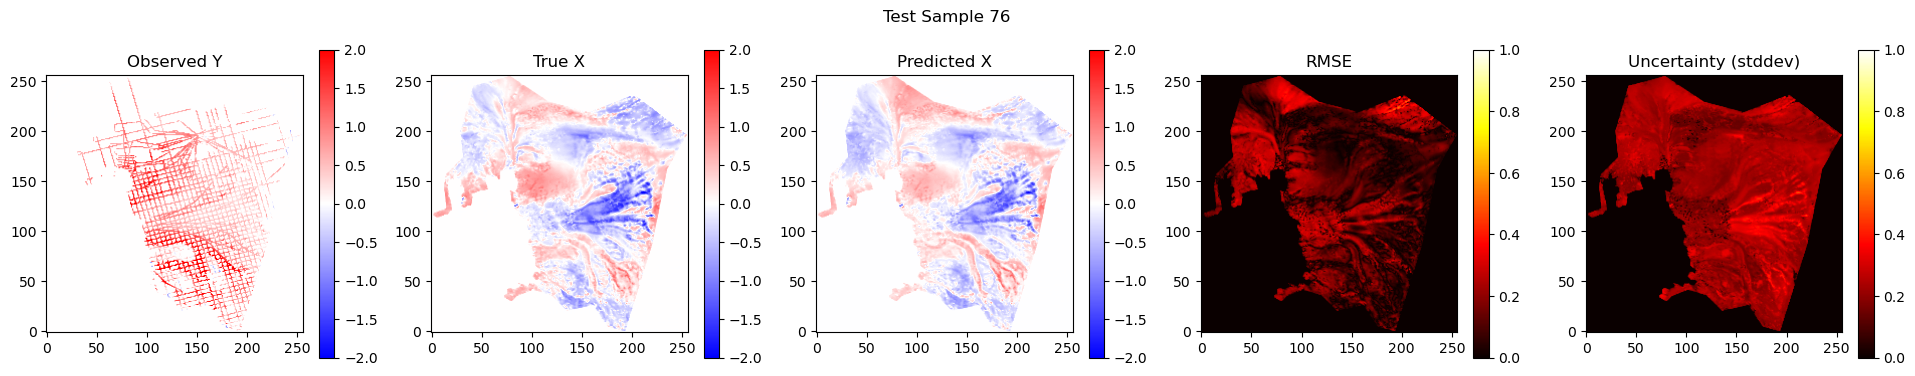

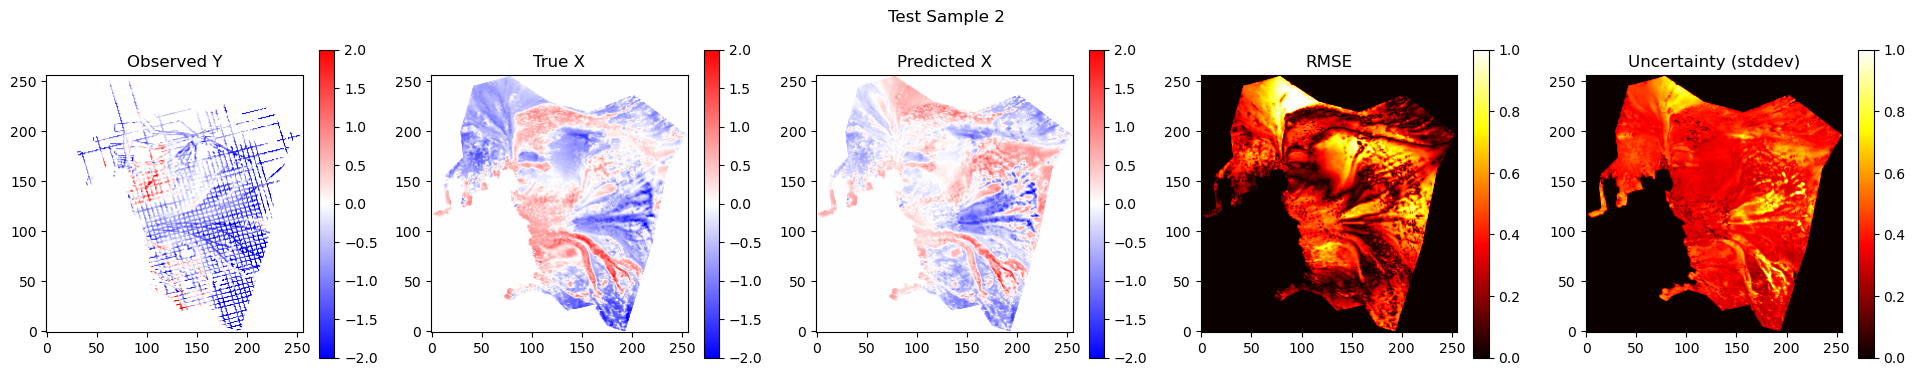

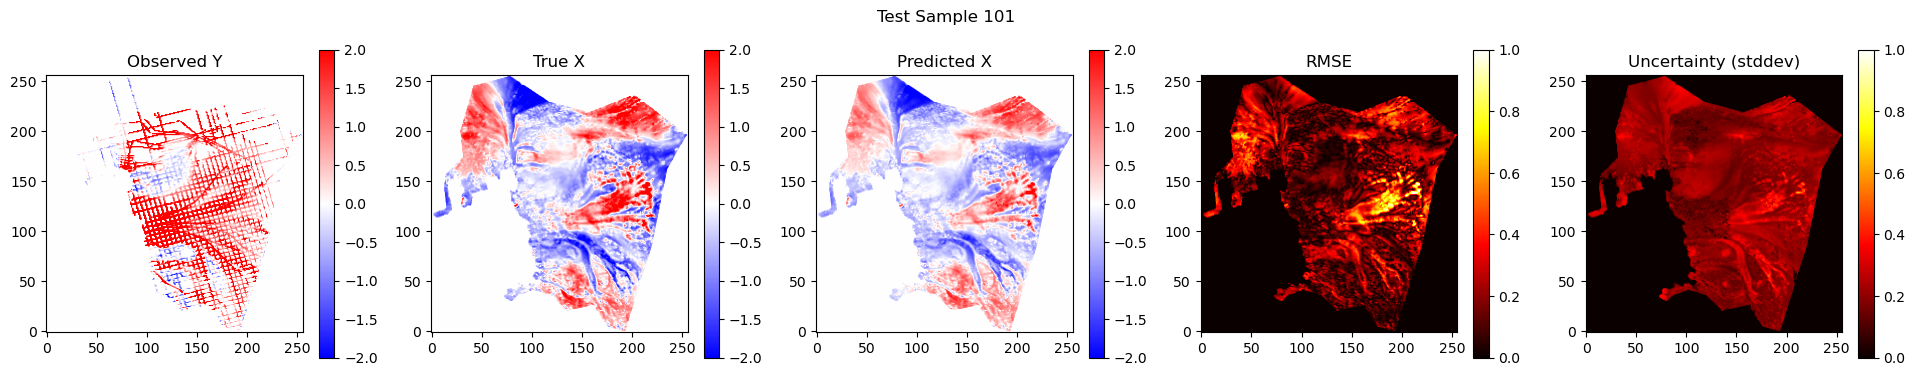

In [ ]:
from src.validation import bayesian_information_criterion

# reduce dim with PCA. 
md.reduce(n_component_x=25, n_component_y=8)

# split data and train a GMM
md.split_data(train_ratio=0.8, validation_ratio=0.1, test_ratio=0.1)

y_train = md.XY_train[:, md.y_indices]
x_train = md.XY_train[:, md.x_indices]

gmm_components = np.linspace(1, 20, 20, dtype=int)
bic_list = []
kln_list = []
neg2L_list = []
for n_components in gmm_components:
    md.train_gmm_XY(n_components=n_components)
    bic, kln, neg2L = bayesian_information_criterion(md, x_train, y_train, n = md.n_samples_train)
    bic_list.append(bic)
    kln_list.append(kln)
    neg2L_list.append(neg2L)
    print("n_components:", n_components, "BIC:", bic)

plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.plot(gmm_components, bic_list, marker='o')
plt.xlabel('Number of GMM Components')
plt.ylabel('Bayesian Information Criterion (BIC)')
plt.title('BIC vs Number of GMM Components')
plt.grid()
# plot the component
plt.subplot(1,2,2)
plt.plot(gmm_components, kln_list, marker='o', label='k*ln(n)')
plt.plot(gmm_components, neg2L_list, marker='o', label='-2*L')
plt.xlabel('Number of GMM Components')
plt.ylabel('Component Values')
plt.title('BIC Components vs Number of GMM Components')
plt.legend()
plt.grid()
plt.show()

# based on the BIC sweep plot
n_optimal = 4 
md.train_gmm_XY(n_components=n_optimal)
md.plot_gmm_samples(n_samples=3)

shape of Y_obs: (256, 256)
Using relaxation z-score standardization with epsilon = 0.262291780650704


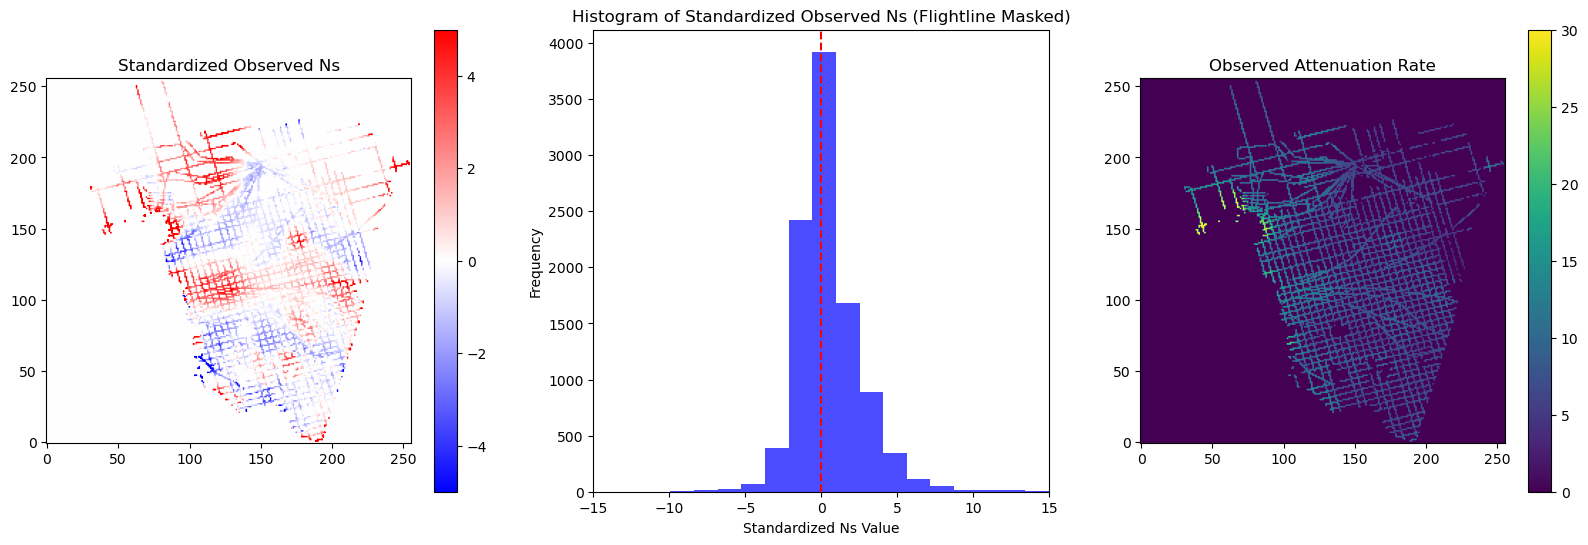

In [61]:
md.load_obs_data(atten_rate_avg)

Density at init: [0.00031298]
 Likelihood: 9.692, Prior: 8.069
 Likelihood: 9.732, Prior: 8.908
 Likelihood: 9.348, Prior: 8.156
 Likelihood: 9.334, Prior: 8.159
 Likelihood: 9.308, Prior: 8.173
 Likelihood: 9.295, Prior: 8.185
 Likelihood: 9.295, Prior: 8.184
 Likelihood: 9.295, Prior: 8.184
 Likelihood: 9.296, Prior: 8.183
 Likelihood: 9.296, Prior: 8.183
 Likelihood: 9.296, Prior: 8.183
Optimization success: True
CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations: 9
Function evaluations: 11
Final objective: 17.4790
Density at init: [0.00031298]
 Likelihood: 4.498, Prior: 8.069
 Likelihood: 4.319, Prior: 8.250
 Likelihood: 4.368, Prior: 8.114
 Likelihood: 4.363, Prior: 8.116
 Likelihood: 4.362, Prior: 8.116
 Likelihood: 4.358, Prior: 8.119
 Likelihood: 4.358, Prior: 8.119
 Likelihood: 4.358, Prior: 8.119
 Likelihood: 4.358, Prior: 8.119
 Likelihood: 4.358, Prior: 8.119
 Likelihood: 4.358, Prior: 8.119
Optimization success: True
CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL

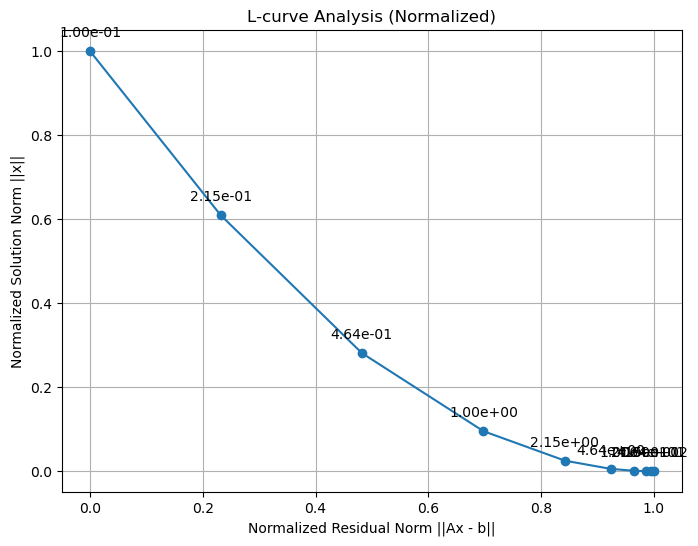

Density at init: [0.00031298]
 Likelihood: 0.969, Prior: 8.069
 Likelihood: 0.955, Prior: 8.078
 Likelihood: 0.957, Prior: 8.075
 Likelihood: 0.957, Prior: 8.074
 Likelihood: 0.957, Prior: 8.075
 Likelihood: 0.957, Prior: 8.075
 Likelihood: 0.957, Prior: 8.075
 Likelihood: 0.957, Prior: 8.075
 Likelihood: 0.957, Prior: 8.075
 Likelihood: 0.957, Prior: 8.075
Optimization success: True
CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Iterations: 8
Function evaluations: 10
Final objective: 9.0318


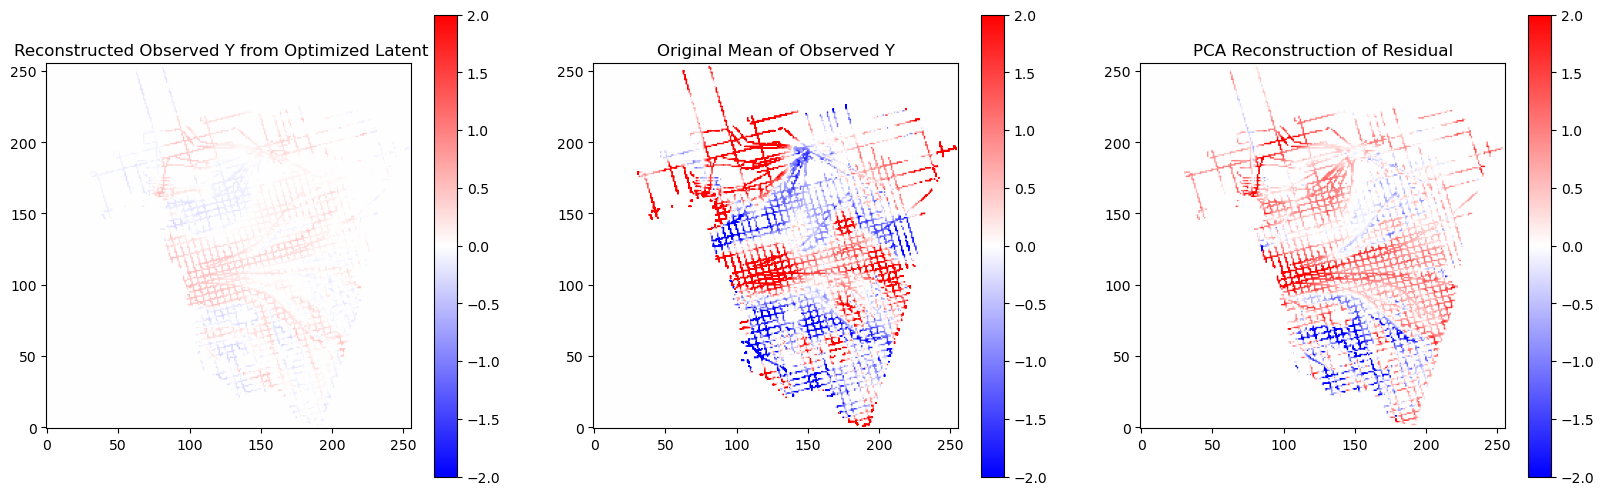

first 5x5 block of cov_obs_latent:
[[8592.78203211  703.33951333 -997.17653264  730.7695268 ]
 [ 703.33951333  920.38153307 -440.10462355  322.52568825]
 [-997.17653264 -440.10462355  905.83097875 -457.26856148]
 [ 730.7695268   322.52568825 -457.26856148  419.33359026]]
min eigenvalue: 19.778856513889252
conditioned indices are:  [0 1 2 3 4 5 6 7]


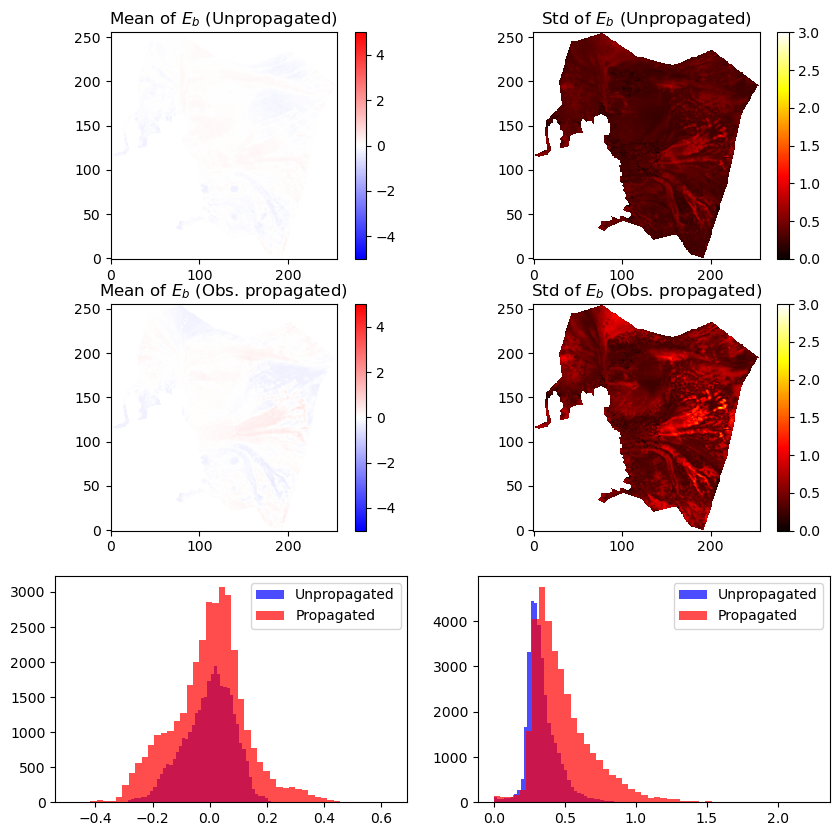

In [137]:
from src.validation import lcurve_analysis
def opt_func(beta):
    return md.compute_optimal_Y_in_latent(beta=beta, show_plot=False)

beta_prior_list = np.logspace(-1, 2, 10)
lcurve_analysis(opt_func=opt_func, beta_prior_list=beta_prior_list)

# the beta_prior comes from the L-curve plot
beta_prior = 1
lambda1, lambda2 = 1,1
md.derive_prior(beta=beta_prior, lambda1=lambda1, lambda2=lambda2)

## Part (iv): loading basal thermal evidence

In [138]:
from src.ice import compute_pmp

# load the thawed base and frozen base data
frozen_base_filename = folder + "../../basal-frozen-mask/frozen_mask.mat"
thawed_base_filename = folder + "../../basal-water-mask/water_mask.mat"
frozen_mask = scipy.io.loadmat(frozen_base_filename)['frozen_mask']
thawed_mask = scipy.io.loadmat(thawed_base_filename)['water_mask']
frozen_mask_data = frozen_mask['data'][0][0]
thawed_mask_data = thawed_mask['data'][0][0]

Eb_mean_data = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std_data = scipy.io.loadmat(folder + Eb_std_filename)
# replace nan by 0
Eb_mean_data = np.nan_to_num(Eb_mean_data['Eb_mean'], nan=0.0)
Eb_std_data = np.nan_to_num(Eb_std_data['Eb_std'], nan=0.0)

# compute pmp
H = H_data['H_struct']['H'][0][0].flatten()
X = H_data['H_struct']['X'][0][0].flatten()
Y = H_data['H_struct']['Y'][0][0].flatten()
pmp = compute_pmp(H)

# into a vector
Eb_mean_data = Eb_mean_data.flatten()
Eb_std_data = Eb_std_data.flatten()
frozen_mask_data = frozen_mask_data.flatten()
thawed_mask_data = thawed_mask_data.flatten()

# set fractional area to 1 for all locations (assumption for now, can be relaxed later)
thawed_fractional_area = np.zeros_like(thawed_mask_data)
frozen_fractional_area = np.zeros_like(frozen_mask_data)
thawed_fractional_area[thawed_mask_data == 1] = 1.0
frozen_fractional_area[frozen_mask_data == 1] = 1.0

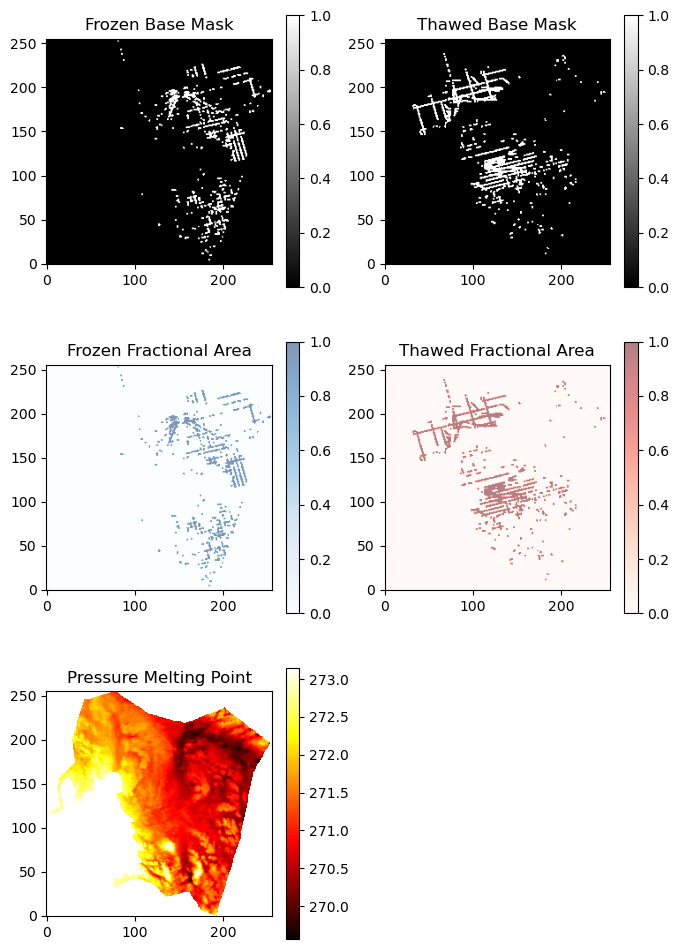

In [139]:
md.load_evidence(thawed_mask_data, thawed_fractional_area,
                 frozen_mask_data, frozen_fractional_area,
                 pmp,
                 show_plot=True)

## Part (v): Computing MAP and posterior distribution

Starting iteration 1/20...
Iteration 1/20, Negative Log Posterior: 2905.4854
Starting iteration 2/20...
Iteration 2/20, Negative Log Posterior: 2895.7540
Starting iteration 3/20...
Iteration 3/20, Negative Log Posterior: 2895.6802
Starting iteration 4/20...
Iteration 4/20, Negative Log Posterior: 2895.6752
Starting iteration 5/20...
Iteration 5/20, Negative Log Posterior: 2895.6752
Starting iteration 6/20...
Iteration 6/20, Negative Log Posterior: 2895.6752
Starting iteration 7/20...
Iteration 7/20, Negative Log Posterior: 2895.6752
Starting iteration 8/20...
Iteration 8/20, Negative Log Posterior: 2895.6763
Starting iteration 9/20...
Iteration 9/20, Negative Log Posterior: 2895.6760
Starting iteration 10/20...
Iteration 10/20, Negative Log Posterior: 2895.6756
Starting iteration 11/20...
Iteration 11/20, Negative Log Posterior: 2895.6760
Starting iteration 12/20...
Iteration 12/20, Negative Log Posterior: 2895.6754
Starting iteration 13/20...
Iteration 13/20, Negative Log Posterior: 2

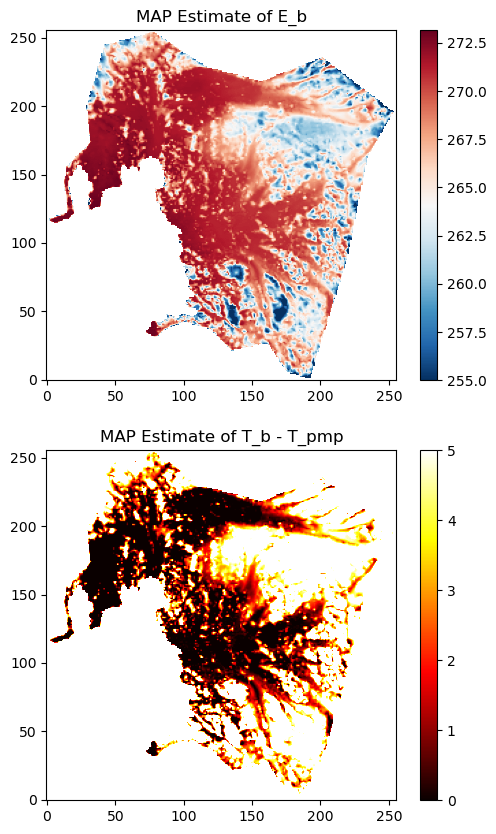

In [140]:
beta_posterior = 2
md.compute_MAP(beta=beta_posterior, n_iter=20, lr=0.5)

Total consistent points: 5268 out of 6403 (82.27%)


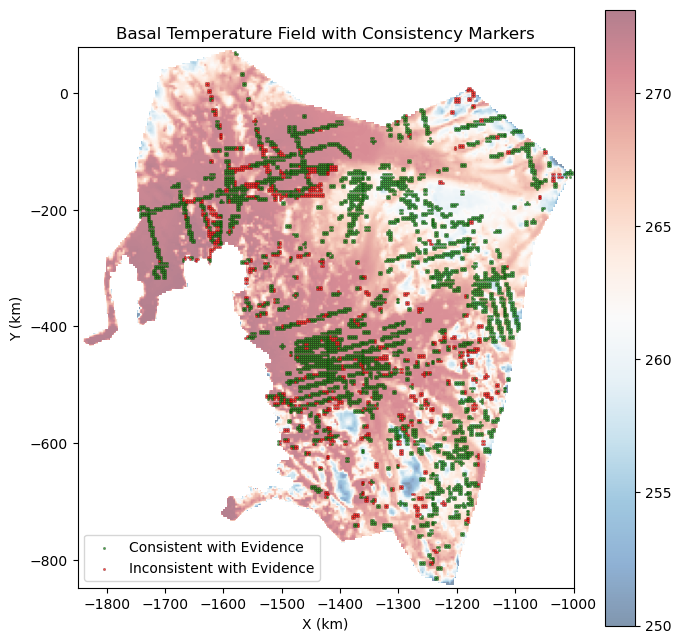

In [107]:
md.plot_evidence_consistency(md.Tb_MAP.flatten(), beta=beta_posterior)

In [24]:
md.derive_posterior(beta=beta_posterior)

Starting HMC sampling: 4000 samples, 1000 warmup...


Sample: 100%|██████████| 5000/5000 [44:24,  1.88it/s, step size=1.53e-01, acc. prob=0.794]


In [28]:
md.analyze_posterior_samples(beta=beta_posterior, loading=True)

HMC Sampling Complete. Extracted shape: (4000, 25)


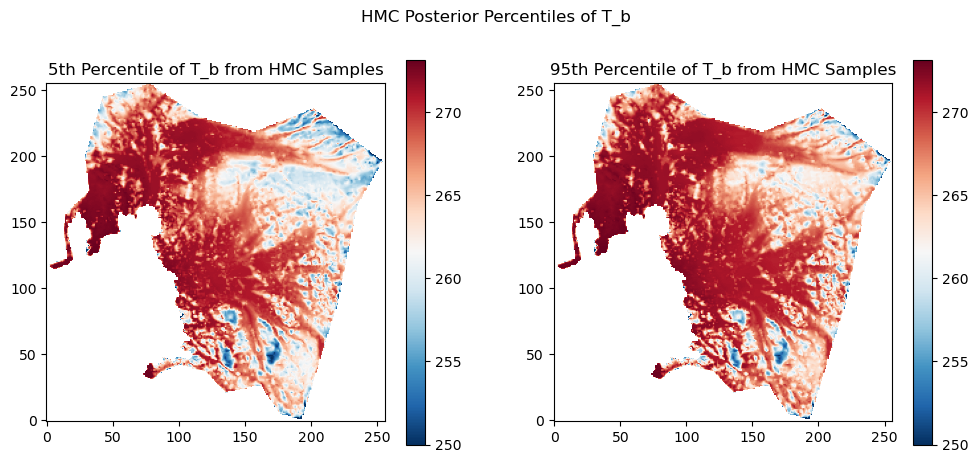

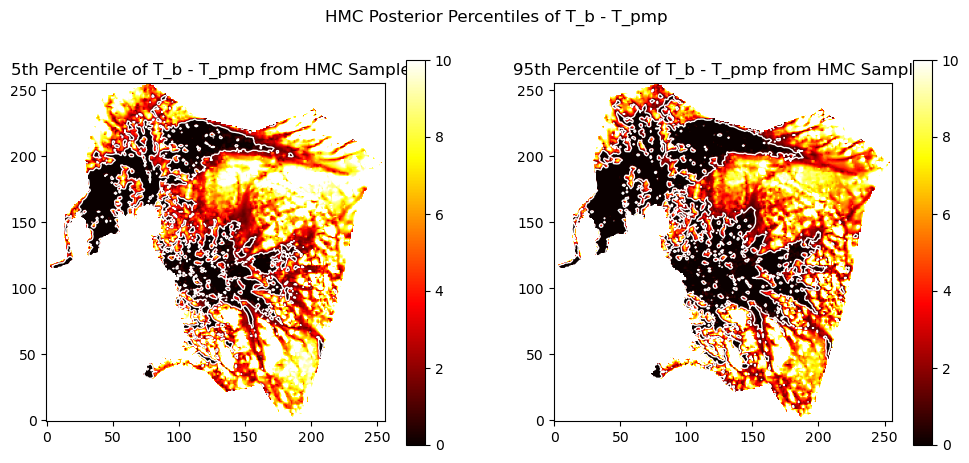

In [29]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(md.Tb_p5, cmap='RdBu_r', vmin=250, vmax=273.15)
plt.title('5th Percentile of T_b from HMC Samples')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 2, 2)
plt.imshow(md.Tb_p95, cmap='RdBu_r', vmin=250, vmax=273.15)
plt.title('95th Percentile of T_b from HMC Samples')
plt.colorbar()
plt.gca().invert_yaxis()
plt.suptitle('HMC Posterior Percentiles of T_b')
plt.show()

deg2pmp_p5 = (md.pmp - md.Tb_p5.flatten()).reshape(md.nx, md.ny)
deg2pmp_p95 = (md.pmp - md.Tb_p95.flatten()).reshape(md.nx, md.ny)
deg2pmp_p5[md.domain_mask == False] = np.nan
deg2pmp_p95[md.domain_mask == False] = np.nan
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(deg2pmp_p5, cmap='hot', vmin=0, vmax=10)
plt.colorbar()  
# add contourline of 1
plt.contour(deg2pmp_p5, levels=[1], colors='white', linewidths=1)
plt.title('5th Percentile of T_b - T_pmp from HMC Samples')
plt.gca().invert_yaxis()
plt.subplot(1, 2, 2)
plt.imshow(deg2pmp_p95 , cmap='hot', vmin=0, vmax=10)
plt.colorbar()
# add contourline of 1
plt.contour(deg2pmp_p95, levels=[1], colors='white', linewidths=1)
plt.title('95th Percentile of T_b - T_pmp from HMC Samples')
plt.gca().invert_yaxis()
plt.suptitle('HMC Posterior Percentiles of T_b - T_pmp')
plt.show()

In [1]:
# plot 5pc and 95 pc differences
plt.figure(figsize=(6,6))
plt.imshow(deg2pmp_p95 - deg2pmp_p5, cmap='hot', vmin=0, vmax=5)
plt.colorbar()
plt.title('Difference between 95th and 5th Percentiles of T_b - T_pmp')
plt.gca().invert_yaxis()
plt.show()

NameError: name 'plt' is not defined

--- HMC Sampling Metrics ---
Total Samples Drawn: 4000
Mean ESS across all dimensions: 1915.29
Minimum ESS (Worst mixing dimension): 977.52
Maximum ESS (Best mixing dimension): 3154.46
Post-Burn-in Mean ESS: 1582.92
Post-Burn-in Min ESS: 737.66


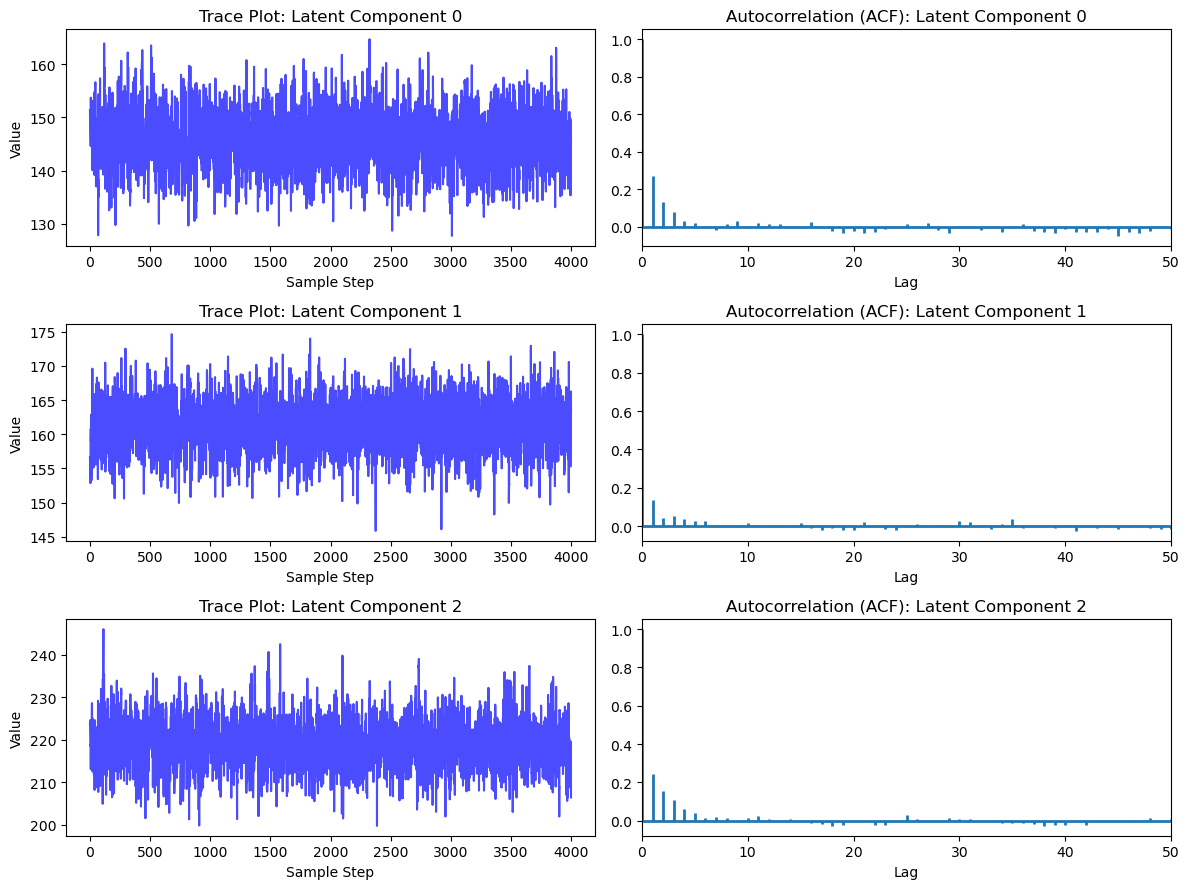

In [30]:
md.posterior_quality_check(slicing=1000)